# A1.3 Solución de problemas y selección de características

## Introducción

En esta actividad se analizará un conjunto de datos con información académica y demográfica de estudiantes. El objetivo es desarrollar un modelo de regresión lineal múltiple que permita predecir la calificación final (G3).

Antes de construir el modelo se realizará una exploración y preparación de los datos, revisando los tipos de variables, posibles valores faltantes, valores atípicos y las relaciones entre las características. Después se realizará una selección de variables y finalmente se evaluará el desempeño del modelo utilizando datos de entrenamiento y de prueba.


In [1]:
import pandas as pd

# Cargar el conjunto de datos
df = pd.read_csv("A1.3 Calificaciones.csv")

# Mostrar las primeras filas
df.head()

,Escuela,Sexo,Edad,HorasDeEstudio,Reprobadas,Internet,Faltas,G1,G2,G3
0,GP,F,18,2,0,no,6,5,6,6
1,GP,F,17,2,0,yes,4,5,5,6
2,GP,F,15,2,3,yes,10,7,8,10
3,GP,F,15,3,0,yes,2,15,14,15
4,GP,F,16,2,0,no,4,6,10,10


## Exploración y comprensión de los datos

Primero se revisará el tamaño del conjunto de datos, los tipos de variables disponibles, la existencia de valores faltantes y posibles registros duplicados.


In [2]:
# Tamaño del conjunto de datos
print("Filas y columnas:")
print(df.shape)

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

# Valores faltantes
print("\nValores faltantes:")
print(df.isnull().sum())

# Registros duplicados
print("\nRegistros duplicados:")
print(df.duplicated().sum())

Filas y columnas:
(395, 10)

Tipos de datos:
Escuela             str
Sexo                str
Edad              int64
HorasDeEstudio    int64
Reprobadas        int64
Internet            str
Faltas            int64
G1                int64
G2                int64
G3                int64
dtype: object

Valores faltantes:
Escuela           0
Sexo              0
Edad              0
HorasDeEstudio    0
Reprobadas        0
Internet          0
Faltas            0
G1                0
G2                0
G3                0
dtype: int64

Registros duplicados:
3


### Resultados de la exploración inicial

El conjunto de datos contiene 395 registros y 10 variables. Las variables Escuela, Sexo e Internet son de tipo categórico, mientras que Edad, HorasDeEstudio, Reprobadas, Faltas, G1, G2 y G3 están almacenadas como variables numéricas.

No se encontraron valores faltantes en ninguna de las columnas, por lo que no es necesario realizar imputación de datos. También se detectaron 3 registros duplicados, por lo que se revisarán antes de decidir si deben eliminarse o conservarse.


In [3]:
# Mostrar los registros que aparecen duplicados
duplicados = df[df.duplicated(keep=False)]

duplicados

,Escuela,Sexo,Edad,HorasDeEstudio,Reprobadas,Internet,Faltas,G1,G2,G3
22,GP,M,16,2,0,yes,2,15,15,16
115,GP,M,16,2,0,yes,2,15,15,16
190,GP,F,16,2,0,yes,10,11,12,13
207,GP,F,16,2,0,yes,10,11,12,13
316,GP,F,18,2,0,yes,0,8,8,0
333,GP,F,18,2,0,yes,0,8,8,0


### Revisión de registros duplicados

Se encontraron 3 pares de registros con los mismos valores en todas las variables disponibles. Sin embargo, el conjunto de datos no contiene un identificador único para cada estudiante, por lo que no es posible asegurar que estos registros correspondan a duplicados por error.

Por esta razón, se decidió conservarlos, ya que podrían representar estudiantes diferentes que coinciden en las características incluidas en el conjunto de datos. Eliminarlos sin evidencia adicional podría provocar la pérdida de observaciones válidas.


### Tipos de variables

Las variables del conjunto de datos pueden clasificarse de la siguiente manera:

- **Escuela:** cualitativa nominal.
- **Sexo:** cualitativa nominal.
- **Edad:** cuantitativa discreta.
- **HorasDeEstudio:** ordinal.
- **Reprobadas:** cuantitativa discreta.
- **Internet:** cualitativa nominal.
- **Faltas:** cuantitativa discreta.
- **G1:** cuantitativa.
- **G2:** cuantitativa.
- **G3:** cuantitativa y corresponde a la variable objetivo que se busca predecir.

Las variables categóricas no pueden utilizarse directamente en una regresión lineal, por lo que posteriormente será necesario transformarlas a una representación numérica.


In [4]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,Edad,HorasDeEstudio,Reprobadas,Faltas,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.035443,0.334177,5.708861,10.908861,10.713924,10.415190
std,1.276043,0.839240,0.743651,8.003096,3.319195,3.761505,4.581443
min,15.000000,1.000000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,1.000000,0.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,2.000000,0.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,2.000000,0.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,3.000000,75.000000,19.000000,19.000000,20.000000


### Estadísticas descriptivas

Las edades de los estudiantes se encuentran entre 15 y 22 años, con un promedio aproximado de 16.7 años. Las horas de estudio se encuentran en una escala de 1 a 4 y tienen un promedio cercano a 2.

La mayoría de los estudiantes no presenta materias reprobadas, ya que la mediana de esta variable es 0. En cuanto a las faltas, el promedio es de aproximadamente 5.7, aunque se observa un valor máximo de 75, considerablemente mayor que el tercer cuartil de 8. Este valor será revisado posteriormente como un posible valor atípico.

Respecto a las calificaciones, los promedios de G1, G2 y G3 son aproximadamente 10.9, 10.7 y 10.4, respectivamente. G3, que será la variable objetivo del modelo, presenta valores entre 0 y 20.


In [5]:
# Revisar los valores de las variables categóricas
columnas_categoricas = ["Escuela", "Sexo", "Internet"]

for columna in columnas_categoricas:
    print("\n", columna)
    print(df[columna].value_counts())


 Escuela
Escuela
GP    349
MS     46
Name: count, dtype: int64

 Sexo
Sexo
F    208
M    187
Name: count, dtype: int64

 Internet
Internet
yes    329
no      66
Name: count, dtype: int64


### Revisión de variables categóricas

Las variables categóricas presentan categorías consistentes. La variable Escuela contiene dos categorías, GP y MS; Sexo contiene F y M; e Internet contiene yes y no. No se observaron valores faltantes ni categorías con errores de escritura.

Debido a que estas variables están representadas mediante texto, será necesario codificarlas numéricamente antes de utilizarlas en el modelo de regresión.


## Preparación y limpieza de los datos

Como parte de la preparación de los datos se revisarán posibles valores atípicos. En las estadísticas descriptivas se observó que la variable Faltas alcanza un valor máximo de 75, mientras que el 75 % de los estudiantes presenta 8 faltas o menos. Por esta razón se analizará su distribución antes de decidir si es necesario realizar alguna modificación.


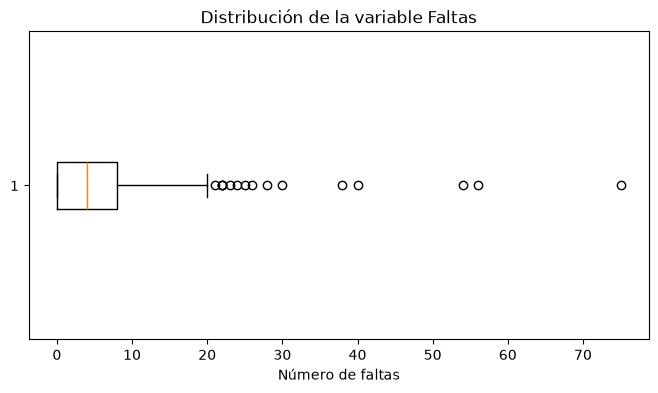

In [6]:
import matplotlib.pyplot as plt

# Diagrama de caja de la variable Faltas
plt.figure(figsize=(8, 4))
plt.boxplot(df["Faltas"], orientation="horizontal")

plt.title("Distribución de la variable Faltas")
plt.xlabel("Número de faltas")

plt.show()

In [7]:
# Calcular los límites para detectar valores atípicos en Faltas
Q1 = df["Faltas"].quantile(0.25)
Q3 = df["Faltas"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

# Mostrar los registros considerados atípicos
atipicos_faltas = df[
    (df["Faltas"] < limite_inferior) |
    (df["Faltas"] > limite_superior)
]

print("\nCantidad de valores atípicos:", len(atipicos_faltas))

atipicos_faltas

Q1: 0.0
Q3: 8.0
IQR: 8.0
Límite inferior: -12.0
Límite superior: 20.0

Cantidad de valores atípicos: 15


,Escuela,Sexo,Edad,HorasDeEstudio,Reprobadas,Internet,Faltas,G1,G2,G3
40,GP,F,16,2,1,yes,25,7,10,11
74,GP,F,16,2,0,yes,54,11,12,11
103,GP,F,15,2,0,yes,26,7,6,6
183,GP,F,17,2,0,yes,56,9,9,8
198,GP,F,17,1,1,yes,24,18,18,18
205,GP,F,17,3,1,yes,28,10,9,9
216,GP,F,17,2,2,yes,22,6,6,4
260,GP,F,18,2,0,yes,21,17,18,18
276,GP,F,18,2,0,yes,75,10,9,9
277,GP,M,18,1,0,yes,22,9,9,9


### Tratamiento de valores atípicos

Mediante el método del rango intercuartílico (IQR) se identificaron 15 registros con más de 20 faltas, los cuales son considerados posibles valores atípicos. El valor máximo observado es de 75 faltas.

Aunque estos valores se encuentran alejados de la mayoría de las observaciones, no existe evidencia dentro del conjunto de datos que indique que sean errores de captura. Por esta razón se decidió conservarlos en el análisis. Eliminarlos únicamente por ser valores extremos podría provocar la pérdida de información válida.

La presencia de estos valores se tendrá en cuenta posteriormente al interpretar el desempeño y las posibles limitaciones del modelo.


### Separación de los datos

Antes de realizar la selección de características se separará el conjunto de datos en entrenamiento y prueba. El conjunto de entrenamiento se utilizará para analizar y seleccionar las variables del modelo, mientras que el conjunto de prueba se reservará únicamente para la evaluación final.

Esta separación permite evitar fuga de datos, ya que la información del conjunto de prueba no será utilizada para tomar decisiones durante la construcción del modelo.


In [8]:
from sklearn.model_selection import train_test_split

# Separar variables explicativas y variable objetivo
X = df.drop("G3", axis=1)
y = df["G3"]

# Separar 80 % para entrenamiento y 20 % para prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)
print("Objetivo de entrenamiento:", y_train.shape)
print("Objetivo de prueba:", y_test.shape)

Datos de entrenamiento: (316, 9)
Datos de prueba: (79, 9)
Objetivo de entrenamiento: (316,)
Objetivo de prueba: (79,)


## Análisis de relaciones entre variables

Para conocer qué variables numéricas tienen mayor relación con la calificación final y detectar posibles relaciones fuertes entre las variables explicativas, se analizará la matriz de correlación.

Este análisis se realizará únicamente con los datos de entrenamiento para evitar utilizar información del conjunto de prueba durante la selección de características.


In [9]:
# Crear un conjunto temporal únicamente con los datos de entrenamiento
datos_entrenamiento = X_train.copy()
datos_entrenamiento["G3"] = y_train

# Seleccionar únicamente las variables numéricas
datos_numericos = datos_entrenamiento.select_dtypes(include="number")

# Calcular la matriz de correlación
correlaciones = datos_numericos.corr()

correlaciones

,Edad,HorasDeEstudio,Reprobadas,Faltas,G1,G2,G3
Edad,1.000000,0.032411,0.235018,0.154107,-0.028267,-0.116579,-0.146241
HorasDeEstudio,0.032411,1.000000,-0.129183,-0.029558,0.202975,0.153854,0.138200
Reprobadas,0.235018,-0.129183,1.000000,0.023092,-0.346077,-0.335638,-0.373769
Faltas,0.154107,-0.029558,0.023092,1.000000,-0.004218,-0.007070,0.064607
G1,-0.028267,0.202975,-0.346077,-0.004218,1.000000,0.833365,0.791559
G2,-0.116579,0.153854,-0.335638,-0.007070,0.833365,1.000000,0.907924
G3,-0.146241,0.138200,-0.373769,0.064607,0.791559,0.907924,1.000000


In [10]:
# Correlación de cada variable numérica con G3
correlacion_g3 = correlaciones["G3"].sort_values(ascending=False)

correlacion_g3

G3                1.000000
G2                0.907924
G1                0.791559
HorasDeEstudio    0.138200
Faltas            0.064607
Edad             -0.146241
Reprobadas       -0.373769
Name: G3, dtype: float64

### Interpretación de las correlaciones

La variable numérica con mayor relación con la calificación final G3 es G2, con una correlación aproximada de 0.908. G1 también presenta una relación positiva fuerte con G3, con un valor aproximado de 0.792.

La variable Reprobadas presenta una correlación negativa de aproximadamente -0.374, lo que indica que un mayor número de materias reprobadas tiende a relacionarse con una menor calificación final. En cambio, Edad, HorasDeEstudio y Faltas presentan relaciones más débiles con G3.

También se observa una correlación alta de aproximadamente 0.833 entre G1 y G2. Esto indica que ambas variables contienen información similar y podría existir redundancia al incluirlas juntas en el modelo. Esta relación se tendrá en cuenta durante la selección de características.

Las variables categóricas todavía no forman parte de este análisis de correlación, por lo que serán revisadas por separado antes de realizar la selección final.


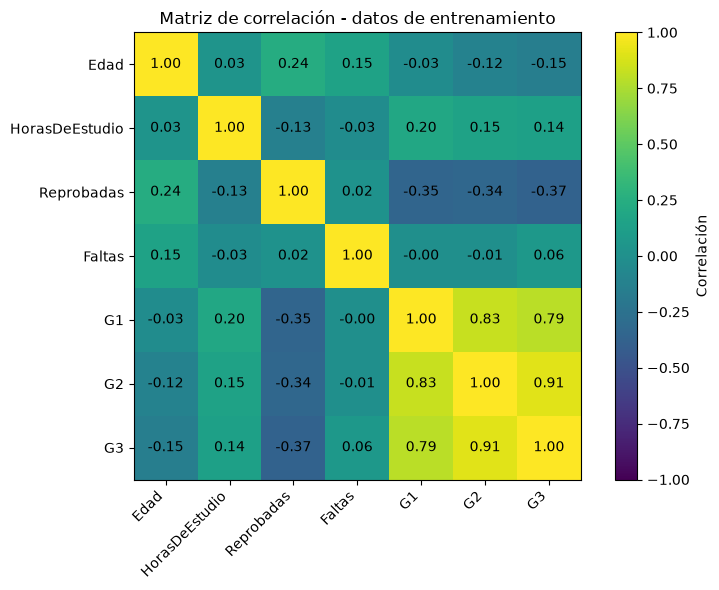

In [11]:
# Visualizar la matriz de correlación
fig, ax = plt.subplots(figsize=(8, 6))

imagen = ax.imshow(correlaciones, vmin=-1, vmax=1)

ax.set_xticks(range(len(correlaciones.columns)))
ax.set_yticks(range(len(correlaciones.index)))

ax.set_xticklabels(correlaciones.columns, rotation=45, ha="right")
ax.set_yticklabels(correlaciones.index)

# Mostrar los valores de correlación dentro de la figura
for i in range(len(correlaciones.index)):
    for j in range(len(correlaciones.columns)):
        ax.text(
            j,
            i,
            f"{correlaciones.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(imagen, label="Correlación")
plt.title("Matriz de correlación - datos de entrenamiento")
plt.tight_layout()
plt.show()

### Relación de las variables categóricas con G3

Las variables Escuela, Sexo e Internet no aparecen en la matriz de correlación porque están representadas mediante categorías de texto. Para revisar su posible relación con la calificación final, se comparará el promedio de G3 entre las categorías de cada variable utilizando únicamente los datos de entrenamiento.


In [12]:
# Agregar las variables categóricas y G3 en un conjunto temporal
datos_categoricos = X_train[["Escuela", "Sexo", "Internet"]].copy()
datos_categoricos["G3"] = y_train

# Promedio de G3 para cada categoría
for columna in ["Escuela", "Sexo", "Internet"]:
    print("\nPromedio de G3 según", columna)
    print(datos_categoricos.groupby(columna)["G3"].mean().round(3))


Promedio de G3 según Escuela
Escuela
GP    10.397
MS     9.735
Name: G3, dtype: float64

Promedio de G3 según Sexo
Sexo
F    10.029
M    10.671
Name: G3, dtype: float64

Promedio de G3 según Internet
Internet
no      9.078
yes    10.566
Name: G3, dtype: float64


### Interpretación de las variables categóricas

Al comparar los promedios de G3 entre las categorías se observan algunas diferencias. Los estudiantes de la escuela GP presentan un promedio de G3 de aproximadamente 10.397, mientras que los de MS presentan 9.735.

En la variable Sexo, el promedio es aproximadamente 10.029 para F y 10.671 para M. La diferencia más notable se observa en Internet, donde los estudiantes sin acceso presentan un promedio de aproximadamente 9.078, mientras que aquellos con acceso presentan 10.566.

Estas diferencias sugieren que algunas variables categóricas podrían aportar información al modelo. Sin embargo, la selección final se realizará considerando también las relaciones observadas en las variables numéricas.


## Selección de características

La selección de características se realizó utilizando únicamente los datos de entrenamiento. Para las variables numéricas se consideraron principalmente aquellas con una correlación absoluta de al menos 0.30 con G3. Además, cuando dos variables explicativas presentan una correlación superior a 0.80 entre ellas, se conserva la que tenga una relación más fuerte con la variable objetivo para reducir posible redundancia.

G1 y G2 presentan una correlación aproximada de 0.833 entre sí. Aunque ambas tienen una relación fuerte con G3, se decidió conservar G2 porque presenta la correlación más alta con la calificación final, aproximadamente 0.908.

También se seleccionó Reprobadas, debido a su correlación negativa de aproximadamente -0.374 con G3. Entre las variables categóricas se seleccionó Internet, ya que fue la que presentó la mayor diferencia en el promedio de G3 entre sus categorías, cercana a 1.5 puntos.

Por lo tanto, las características seleccionadas para construir el modelo son G2, Reprobadas e Internet.


In [13]:
# Seleccionar las características elegidas
X_train_sel = X_train[["G2", "Reprobadas", "Internet"]].copy()
X_test_sel = X_test[["G2", "Reprobadas", "Internet"]].copy()

# Convertir Internet a una variable numérica
X_train_sel["Internet"] = X_train_sel["Internet"].map({"no": 0, "yes": 1})
X_test_sel["Internet"] = X_test_sel["Internet"].map({"no": 0, "yes": 1})

print("Datos de entrenamiento seleccionados:")
display(X_train_sel.head())

print("\nDatos de prueba seleccionados:")
display(X_test_sel.head())

Datos de entrenamiento seleccionados:


,G2,Reprobadas,Internet
181,13,0,1
194,14,0,1
173,7,3,1
63,9,0,1
253,9,0,0



Datos de prueba seleccionados:


,G2,Reprobadas,Internet
78,8,3,1
371,12,0,1
248,5,1,1
55,9,0,1
390,9,2,0


## Entrenamiento del modelo

Con las características seleccionadas se entrenará un modelo de regresión lineal múltiple. El modelo utilizará G2, Reprobadas e Internet como variables explicativas para predecir la calificación final G3.

El entrenamiento se realizará únicamente con los datos de entrenamiento previamente separados. Después se generarán predicciones tanto para entrenamiento como para prueba con el fin de comparar el desempeño del modelo en ambos conjuntos.


In [14]:
from sklearn.linear_model import LinearRegression

# Crear el modelo
modelo = LinearRegression()

# Entrenar el modelo
modelo.fit(X_train_sel, y_train)

# Realizar predicciones
y_train_pred = modelo.predict(X_train_sel)
y_test_pred = modelo.predict(X_test_sel)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [15]:
# Mostrar intercepto y coeficientes del modelo
print("Intercepto:", round(modelo.intercept_, 3))

coeficientes = pd.DataFrame({
    "Variable": X_train_sel.columns,
    "Coeficiente": modelo.coef_
})

coeficientes["Coeficiente"] = coeficientes["Coeficiente"].round(3)

coeficientes

Intercepto: -0.92


,Variable,Coeficiente
0,G2,1.079
1,Reprobadas,-0.485
2,Internet,-0.102


In [16]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Métricas de entrenamiento
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

# Métricas de prueba
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

# Crear tabla de resultados
metricas = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R2": [r2_train, r2_test]
})

metricas.round(3)

,Conjunto,MAE,RMSE,R2
0,Entrenamiento,1.110,1.891,0.830
1,Prueba,1.228,2.144,0.776


### Interpretación del modelo

El coeficiente de G2 es aproximadamente 1.079, por lo que, manteniendo constantes las demás variables, un aumento de un punto en G2 se relaciona con un incremento aproximado de 1.079 puntos en la calificación final G3.

La variable Reprobadas presenta un coeficiente de aproximadamente -0.485. Esto indica que, manteniendo las demás variables constantes, un mayor número de materias reprobadas se relaciona con una disminución en la calificación final.

Internet presenta un coeficiente pequeño de aproximadamente -0.102. Aunque en el análisis inicial los estudiantes con Internet mostraban un promedio de G3 mayor, al considerar simultáneamente G2 y Reprobadas su contribución adicional al modelo resulta pequeña.

En los datos de entrenamiento se obtuvo un MAE de 1.110, un RMSE de 1.891 y un R² de 0.830. En los datos de prueba se obtuvo un MAE de 1.228, un RMSE de 2.144 y un R² de 0.776.

El modelo mantiene un desempeño similar entre entrenamiento y prueba. El R² de prueba indica que aproximadamente el 77.6 % de la variación observada en G3 puede ser explicada por las características utilizadas. La diferencia moderada entre las métricas de entrenamiento y prueba sugiere que no existe un sobreajuste fuerte.


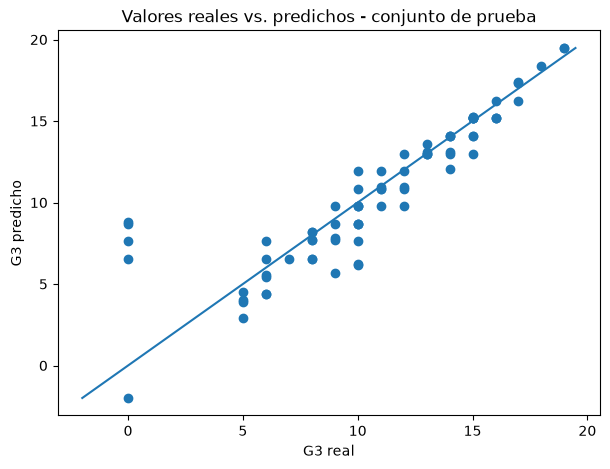

In [17]:
# Comparar valores reales y predichos en el conjunto de prueba
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_test_pred)

# Línea de referencia para predicciones perfectas
minimo = min(y_test.min(), y_test_pred.min())
maximo = max(y_test.max(), y_test_pred.max())

plt.plot([minimo, maximo], [minimo, maximo])

plt.xlabel("G3 real")
plt.ylabel("G3 predicho")
plt.title("Valores reales vs. predichos - conjunto de prueba")

plt.show()

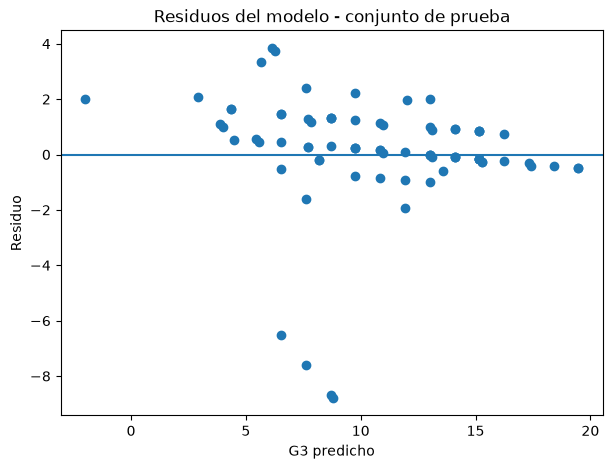

In [18]:
# Calcular residuos del conjunto de prueba
residuos = y_test - y_test_pred

plt.figure(figsize=(7, 5))

plt.scatter(y_test_pred, residuos)
plt.axhline(y=0)

plt.xlabel("G3 predicho")
plt.ylabel("Residuo")
plt.title("Residuos del modelo - conjunto de prueba")

plt.show()

### Interpretación de las visualizaciones

En la comparación entre los valores reales y predichos se observa que gran parte de las predicciones se encuentra cerca de la línea de referencia, lo que indica que el modelo logra representar de manera adecuada la tendencia general de las calificaciones finales.

Sin embargo, también existen algunos casos con diferencias importantes entre el valor real y el predicho. Esto se observa principalmente en estudiantes con una calificación final igual a 0, donde el modelo en algunos casos genera predicciones considerablemente mayores. También se observa una predicción negativa, lo cual es posible debido a que la regresión lineal no restringe automáticamente sus resultados al rango de calificaciones de 0 a 20.

En la gráfica de residuos, la mayoría de los errores se encuentra relativamente cerca de cero, aunque existen algunos residuos de mayor magnitud. Estos casos explican en parte que el RMSE sea superior al MAE. En general, el modelo representa adecuadamente la tendencia de los datos, pero presenta mayor dificultad en algunos casos extremos.


## Limitaciones y posibles mejoras

Aunque el modelo obtuvo un buen desempeño general, presenta algunas limitaciones. Una de ellas es que la regresión lineal puede generar predicciones fuera del rango real de las calificaciones, como se observó en un caso con una predicción negativa. Además, algunos estudiantes con G3 igual a 0 presentan errores de predicción considerablemente mayores.

Otra limitación es que el modelo utiliza únicamente G2, Reprobadas e Internet. Estas variables permiten explicar una parte importante de la calificación final, pero existen otros factores académicos o personales que podrían influir y que no están disponibles en este conjunto de datos.

Como posibles mejoras futuras se podría comparar el desempeño con otros métodos de selección de características y con otros modelos predictivos. También sería posible estudiar con mayor detalle los casos extremos y evaluar estrategias que mantengan las predicciones dentro del rango válido de calificaciones.


## Conclusión

En esta actividad se desarrolló un modelo de regresión lineal múltiple para predecir la calificación final G3. Antes de entrenar el modelo se realizó una exploración y preparación del conjunto de datos, revisando los tipos de variables, valores faltantes, registros duplicados y posibles valores atípicos.

La selección de características permitió reducir el conjunto original a G2, Reprobadas e Internet. G2 presentó la relación más fuerte con la calificación final, mientras que Reprobadas mostró una relación negativa. Internet fue seleccionada como la variable categórica con mayor diferencia inicial entre los promedios de G3 de sus categorías.

El modelo obtuvo un R² de 0.830 en entrenamiento y de 0.776 en prueba. En el conjunto de prueba presentó un MAE de 1.228 y un RMSE de 2.144. Estos resultados muestran que el modelo logra explicar una parte importante de la variación de la calificación final y mantiene un desempeño relativamente similar entre entrenamiento y prueba.

El análisis también mostró que la preparación y selección de características son pasos importantes antes de construir un modelo, ya que permiten identificar datos problemáticos, reducir información redundante y utilizar variables con mayor utilidad predictiva. A pesar del buen desempeño general, se observaron errores mayores en algunos casos extremos, por lo que el modelo todavía podría mejorarse.
